# Audio Preprocessing and Visualization

### Import Required Libraries

In [2]:
import librosa
import numpy as np
import matplotlib.pyplot as plt 

### Load an Audio Sample

In [3]:
audio_path = "Documents/AIML-Assessment/Module-4/sound.wav.flac"
signal, sr = librosa.load(audio_path,sr=None)

### Preprocessing

### A. Resampling

In [4]:
new_sr=16000
resampled_signal = librosa.resample(
    signal,
    orig_sr=sr,
    target_sr=new_sr
)

### B. Normalization

In [5]:
normalized_signal = resampled_signal / np.max(np.abs(resampled_signal))

### C. Silence Removal

In [6]:
trimmed_signal, _ = librosa.effects.trim(normalized_signal)

### Display Waveform

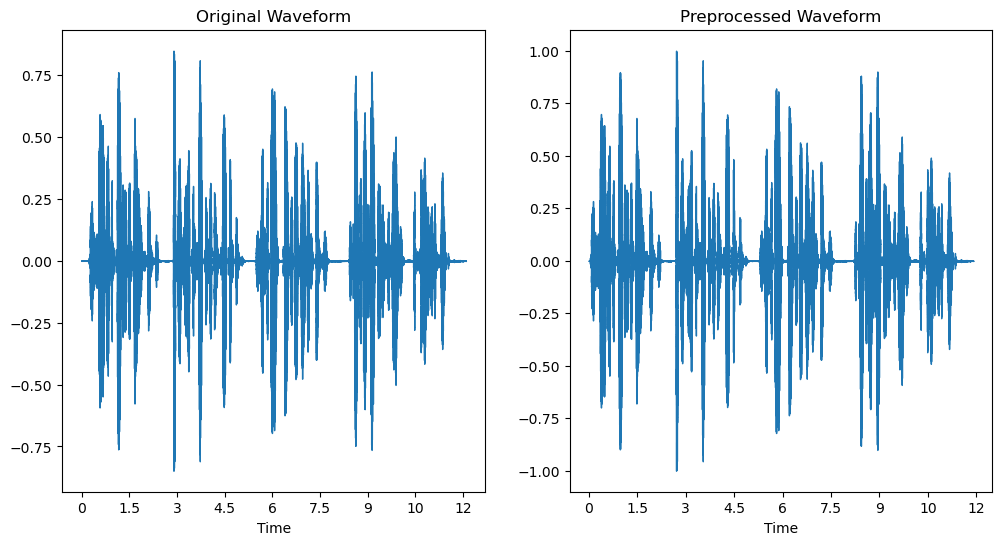

In [7]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
librosa.display.waveshow(signal, sr=new_sr, ax=ax[0])
ax[0].set_title("Original Waveform")
librosa.display.waveshow(trimmed_signal, sr=new_sr, ax=ax[1])
ax[1].set_title("Preprocessed Waveform")
plt.show()

### Mel Spectrogram

In [8]:
mel_original = librosa.feature.melspectrogram(y=signal, sr=sr)
mel_db_original = librosa.power_to_db(mel_original, ref=np.max)
mel_processed = librosa.feature.melspectrogram(y=trimmed_signal, sr=new_sr)
mel_db_processed = librosa.power_to_db(mel_processed, ref=np.max)

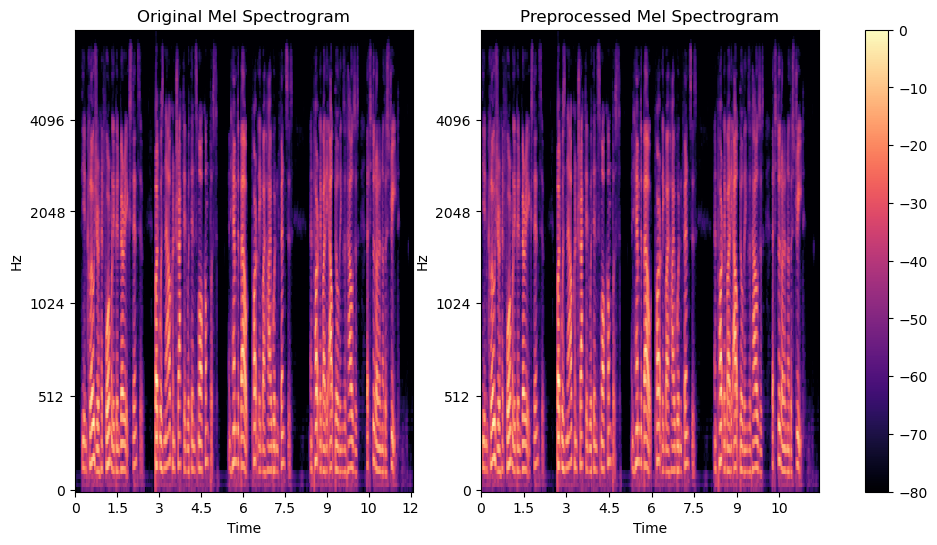

In [10]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
img1 = librosa.display.specshow(
    mel_db_original,
    sr=sr,
    ax=ax[0],
    x_axis='time',
    y_axis='mel'
)
img2 = librosa.display.specshow(
    mel_db_processed,
    sr=new_sr,
    ax=ax[1],
    x_axis='time',
    y_axis='mel'
)
fig.colorbar(img1, ax=ax.ravel())
ax[0].set_title("Original Mel Spectrogram")
ax[1].set_title("Preprocessed Mel Spectrogram")
plt.show()

### MFCC HEATMAP

In [27]:
mfcc_original = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
mfcc_processed = librosa.feature.mfcc(y=trimmed_signal, sr=new_sr, n_mfcc=13)

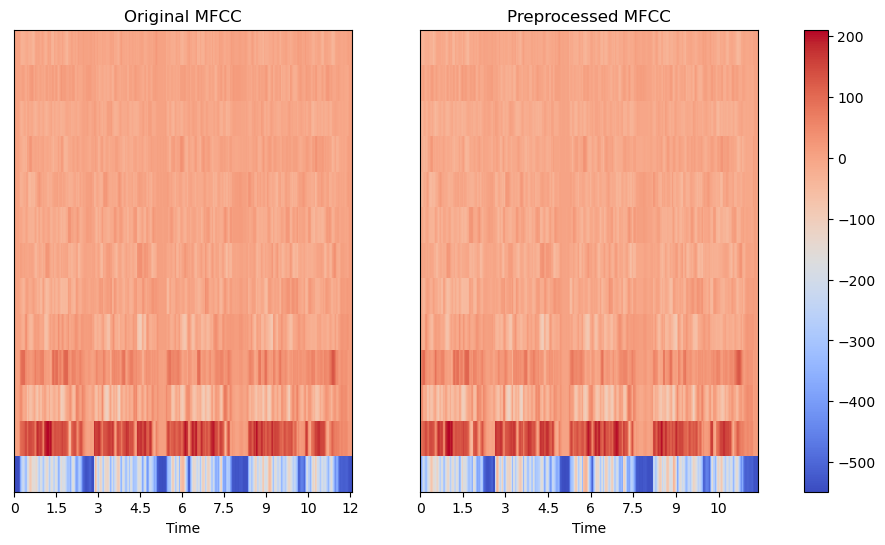

In [33]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
img1 = librosa.display.specshow(
    mfcc_original,
    sr=sr,
    ax=ax[0],
    x_axis='time',
)
img2 = librosa.display.specshow(
    mfcc_processed,
    sr=new_sr,
    ax=ax[1],
    x_axis='time',
)
fig.colorbar(img1, ax=ax)
ax[0].set_title("Original MFCC")
ax[1].set_title("Preprocessed MFCC")
plt.show()

### FFT Spectrum

In [12]:
fft_original = np.fft.fft(signal)
original_magnitude = np.abs(fft_original)
original_frequency =  np.fft.fftfreq(len(fft_original), 1/sr)
fft_processed =  np.fft.fft(trimmed_signal)
processed_magnitude = np.abs(fft_processed)
processed_frequency = np.fft.fftfreq(len(fft_processed), 1/new_sr)

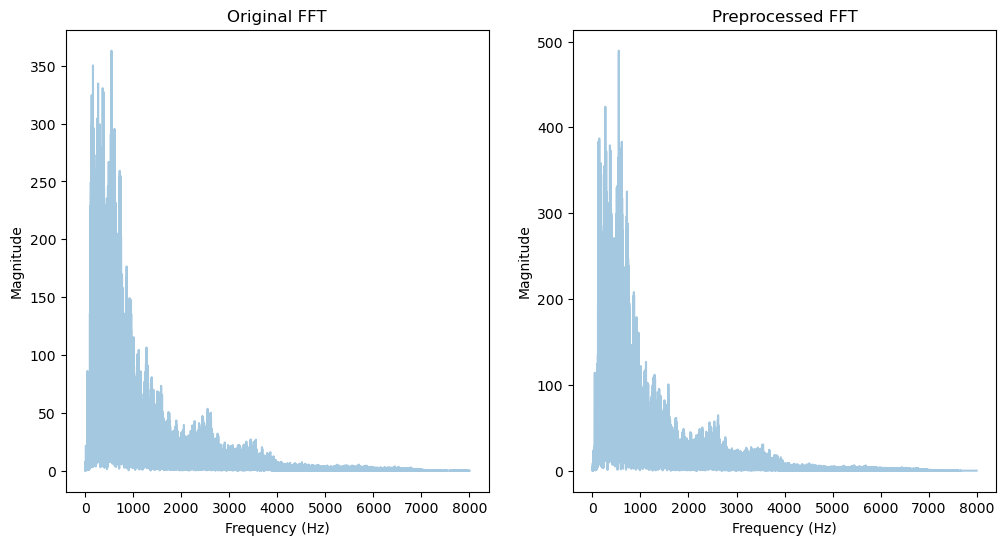

In [14]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].plot(original_frequency[:len(original_frequency)//2], original_magnitude[:len(original_magnitude)//2], alpha=0.4)
ax[1].plot(processed_frequency[:len(processed_frequency)//2], processed_magnitude[:len(processed_magnitude)//2], alpha=0.4)
ax[0].set_title("Original FFT")
ax[1].set_title("Preprocessed FFT")
ax[0].set_xlabel("Frequency (Hz)")
ax[1].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Magnitude")
plt.show()